In [1]:
import os
import pickle
from utils.plots import get_clause_lengths_by_polarity, plot_clause_length_boxplot_by_polarity, plot_literal_clause_frequency
import matplotlib.pyplot as plt
import numpy as np
import config
from utils.statistics import compute_clause_length_statistics, run_mannwhitney_pos_neg_length, run_kruskalwallis_across_specialists, run_posthoc_mannwhitney

In [2]:
CURRENT_DATASET = config.PNEUMONIAMNIST

In [3]:
canny_path = os.path.join("saved_models", "PneumoniaMNIST_Canny_Specialist.pkl")
with open(canny_path, "rb") as f:
    tm_canny = pickle.load(f)
    

tm_gaussian = os.path.join("saved_models", "PneumoniaMNIST_Adaptive_Gaussian_Specialist.pkl")
with open(tm_gaussian, "rb") as f:
    tm_gaussian = pickle.load(f)

tn_mean = os.path.join("saved_models", "PneumoniaMNIST_Adaptive_Mean_Specialist.pkl") 
with open(tn_mean, "rb") as f:
    tm_mean = pickle.load(f)

tm_otsu = os.path.join("saved_models", "PneumoniaMNIST_Otsu_Specialist.pkl")
with open(tm_otsu, "rb") as f:
    tm_otsu = pickle.load(f)

tm_thermo = os.path.join("saved_models", "PneumoniaMNIST_Color_Thermometers_Specialist.pkl")
with open(tm_thermo, "rb") as f:
    tm_thermo = pickle.load(f)

In [4]:
specialists = {
    'Canny': tm_canny,
    'Ad. Gaussian': tm_gaussian,
    'Ad. Mean': tm_mean,
    'Otsu': tm_otsu,
    'Thermometer': tm_thermo,
}

In [5]:
for name, tm in specialists.items():
   print(f"========={name}")
   print(f"Number of Clauses for: {tm.number_of_clauses}")
   print(f"The Patch size is {tm.patch_dim}")
   print(f"The T value is {tm.T}")
   print(f"The s value is {tm.s}")
   print(f"The max included literals is {tm.max_included_literals}")
   print()

=========Canny
Number of Clauses for: 4000
The Patch size is (9, 9)
The T value is 2500
The s value is 13.0
The max included literals is 128

=========Ad. Gaussian
Number of Clauses for: 4000
The Patch size is (9, 9)
The T value is 1000
The s value is 9.0
The max included literals is 128

=========Ad. Mean
Number of Clauses for: 4000
The Patch size is (7, 7)
The T value is 2500
The s value is 10.0
The max included literals is 128

=========Otsu
Number of Clauses for: 4000
The Patch size is (9, 9)
The T value is 2000
The s value is 10.0
The max included literals is 128

=========Thermometer
Number of Clauses for: 4000
The Patch size is (9, 9)
The T value is 4500
The s value is 11.0
The max included literals is 128




--- Clause Length Observations: BreastMNIST | Class 0 ---
  Canny                     Positive:   2000  |  Negative:   2000
  Ad. Gaussian              Positive:   2000  |  Negative:   2000
  Ad. Mean                  Positive:   2000  |  Negative:   2000
  Otsu                      Positive:   2000  |  Negative:   2000
  Thermometer               Positive:   2000  |  Negative:   2000
------------------------------------------------------------
Saved to clause_analysis_plots/pneumonia_clause_length_boxplot_class_0.svg


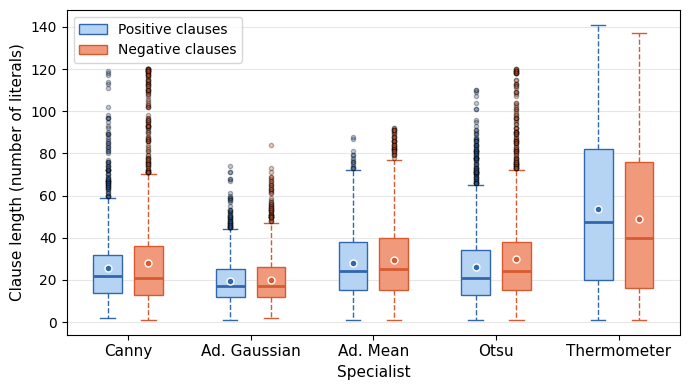


--- Clause Length Observations: BreastMNIST | Class 1 ---
  Canny                     Positive:   2000  |  Negative:   2000
  Ad. Gaussian              Positive:   2000  |  Negative:   2000
  Ad. Mean                  Positive:   2000  |  Negative:   2000
  Otsu                      Positive:   2000  |  Negative:   2000
  Thermometer               Positive:   2000  |  Negative:   1999
------------------------------------------------------------
Saved to clause_analysis_plots/pneumonia_clause_length_boxplot_class_1.svg


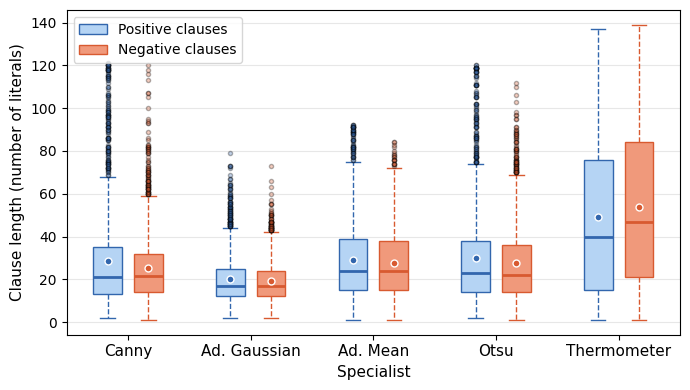

In [6]:
for target_class in [0, 1]:
    data_pos = {}
    data_neg = {}
    for name, tm in specialists.items():
        pos, neg = get_clause_lengths_by_polarity(tm, target_class)
        data_pos[name] = pos
        data_neg[name] = neg

    plot_clause_length_boxplot_by_polarity(
        data_pos, data_neg,
        target_class=target_class,
        figsize=(7, 4), 
        save_path=os.path.join("clause_analysis_plots", f"{CURRENT_DATASET}_clause_length_boxplot_class_{target_class}.svg")
    )

In [7]:
for target_class in [0, 1]:
    data_pos = {}
    data_neg = {}
    for name, tm in specialists.items():
        pos, neg = get_clause_lengths_by_polarity(tm, target_class)
        data_pos[name] = pos
        data_neg[name] = neg
    compute_clause_length_statistics(data_pos, data_neg, dataset_name='PneumoniaMNIST', target_class=target_class)


Clause Length Statistics | PneumoniaMNIST | Class 0
  Specialist                Polarity          n       Mean     Median        Std
  ------------------------- ------------ ------ ---------- ---------- ----------
  Canny                     Positive       2000      25.53      22.00      16.64
                            Negative       2000      28.15      21.00      23.38
  ------------------------- ------------ ------ ---------- ---------- ----------
  Ad. Gaussian              Positive       2000      19.60      17.00      10.51
                            Negative       2000      20.02      17.00      11.53
  ------------------------- ------------ ------ ---------- ---------- ----------
  Ad. Mean                  Positive       2000      27.87      24.00      16.50
                            Negative       2000      29.51      25.00      18.55
  ------------------------- ------------ ------ ---------- ---------- ----------
  Otsu                      Positive       2000      26.

In [8]:
for target_class in [0, 1]:
    data_pos = {}
    data_neg = {}  # make sure these are reset inside the loop
    for name, tm in specialists.items():
        pos, neg = get_clause_lengths_by_polarity(tm, target_class)
        data_pos[name] = pos
        data_neg[name] = neg
    run_mannwhitney_pos_neg_length(data_pos, data_neg, dataset_name='PneumoniaMNIST', target_class=target_class)


Mann-Whitney U — Positive vs Negative Clause Lengths
Dataset: PneumoniaMNIST | Class 0
H0: Positive and negative clause length distributions are identical.
H1: Positive and negative clause length distributions differ.

  Specialist                 n_pos  n_neg     U-stat      p-value   Effect (r)  Reject H0
  ------------------------- ------ ------ ---------- ------------ ------------ ----------
  Canny                       2000   2000  2013080.0        0.720      -0.0065          ✗
  Ad. Gaussian                2000   2000  2003302.0        0.928      -0.0017          ✗
  Ad. Mean                    2000   2000  1935318.5        0.076       0.0323          ✗
  Otsu                        2000   2000  1811018.5     2.26e-07       0.0945          ✓
  Thermometer                 2000   2000  2168186.0     4.11e-06      -0.0841          ✓

  Significance level: α = 0.05




Mann-Whitney U — Positive vs Negative Clause Lengths
Dataset: PneumoniaMNIST | Class 1
H0: Positive and negative clause length distributions are identical.
H1: Positive and negative clause length distributions differ.

  Specialist                 n_pos  n_neg     U-stat      p-value   Effect (r)  Reject H0
  ------------------------- ------ ------ ---------- ------------ ------------ ----------
  Canny                       2000   2000  2029224.5        0.423      -0.0146          ✗
  Ad. Gaussian                2000   2000  2033234.0        0.362      -0.0166          ✗
  Ad. Mean                    2000   2000  2039691.0        0.277      -0.0198          ✗
  Otsu                        2000   2000  2070476.0        0.054      -0.0352          ✗
  Thermometer                 2000   1999  1828447.5     2.98e-06       0.0853          ✓

  Significance level: α = 0.05



In [9]:
for target_class in [0, 1]:
    data_pos = {}
    data_neg = {}
    for name, tm in specialists.items():
        pos, neg = get_clause_lengths_by_polarity(tm, target_class)
        data_pos[name] = pos
        data_neg[name] = neg

    run_kruskalwallis_across_specialists(
        data_pos, data_neg,
        dataset_name='PneumoniaMNIST',
        target_class=target_class
    )


Kruskal-Wallis — Clause Lengths Across Specialists
Dataset: PneumoniaMNIST | Class 0
H0: Clause length distributions are identical across all specialists.
H1: At least one specialist has a different clause length distribution.

  Polarity      H-statistic      p-value  Reject H0
  ------------ ------------ ------------ ----------
  Positive        1156.0327       0.0000          ✓
  Negative         729.9196       0.0000          ✓

  Significance level: α = 0.05


Kruskal-Wallis — Clause Lengths Across Specialists
Dataset: PneumoniaMNIST | Class 1
H0: Clause length distributions are identical across all specialists.
H1: At least one specialist has a different clause length distribution.

  Polarity      H-statistic      p-value  Reject H0
  ------------ ------------ ------------ ----------
  Positive         683.2351       0.0000          ✓
  Negative        1215.4833       0.0000          ✓

  Significance level: α = 0.05



In [10]:
for target_class in [0, 1]:
    data_pos = {}
    data_neg = {}
    for name, tm in specialists.items():
        pos, neg = get_clause_lengths_by_polarity(tm, target_class)
        data_pos[name] = pos
        data_neg[name] = neg
    run_posthoc_mannwhitney(
        data_pos, data_neg,
        dataset_name='PneumoniaMNIST',
        target_class=target_class
    )  



Post-hoc Pairwise Mann-Whitney U — Across Specialists
Dataset: PneumoniaMNIST | Class 0
H0: Clause length distributions are identical for a given pair of specialists.
H1: Clause length distributions differ for a given pair of specialists.

--- Positive clauses ---
  Pair                                              U-stat        p-value   Effect (r)  Reject H0
  --------------------------------------------- ---------- -------------- ------------ ----------
  Canny vs Ad. Gaussian                          2408268.5       4.87e-29      -0.2041          ✓
  Canny vs Ad. Mean                              1808598.5       1.59e-07       0.0957          ✓
  Canny vs Otsu                                  2013360.0          0.714      -0.0067          ✗
  Canny vs Thermometer                           1145582.5      4.37e-121       0.4272          ✓
  Ad. Gaussian vs Ad. Mean                       1414790.0       7.85e-58       0.2926          ✓
  Ad. Gaussian vs Otsu                          